# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

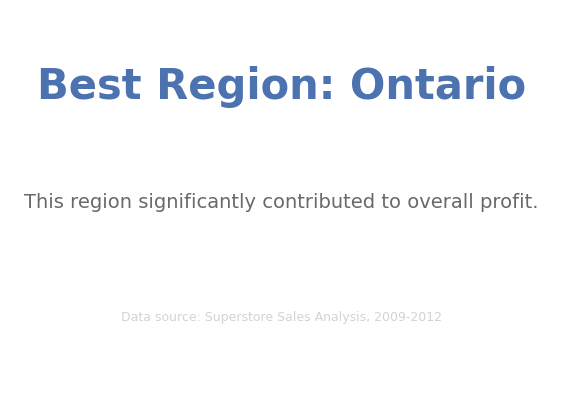

In [6]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1: primary element -- large, bold, colored
ax.text(0.5, 0.8, f"Best Region: {best_region}",
        fontsize=30, fontweight='bold', color='#4C72B0',
        ha='center', va='center', transform=ax.transAxes)

# TODO 2: secondary element -- medium, muted color
ax.text(0.5, 0.5, "This region significantly contributed to overall profit.",
        fontsize=14, color='dimgray',
        ha='center', va='center', transform=ax.transAxes)

# TODO 3: tertiary element -- small, light gray
ax.text(0.5, 0.2, "Data source: Superstore Sales Analysis, 2009-2012",
        fontsize=9, color='lightgray',
        ha='center', va='center', transform=ax.transAxes)

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

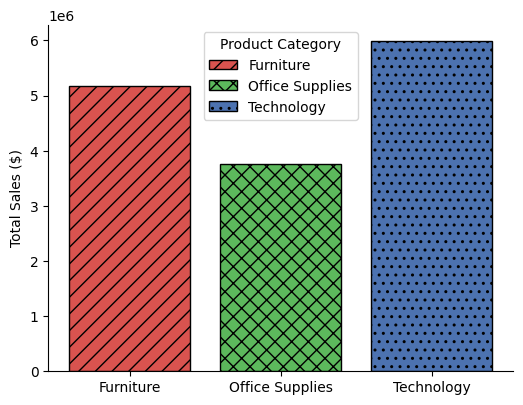

In [7]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat, sales_val in cat_sales.items():
    ax.bar(cat, sales_val, color=colors[cat], hatch=hatches[cat], label=cat, edgecolor='black')

# TODO 3: legend
ax.legend(title="Product Category")
ax.set_ylabel("Total Sales ($)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

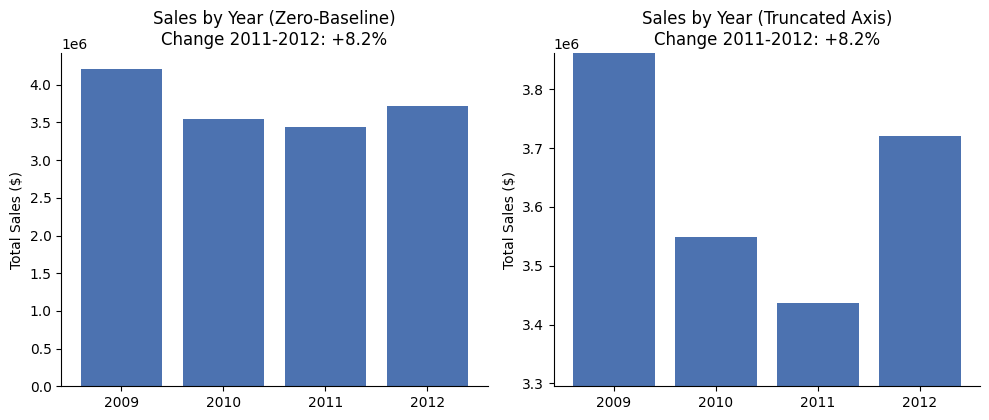

Real change from 2011 to 2012: +8.2%


In [8]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.loc[y1], yearly_sales.loc[y2]
pct_change = ((v2 - v1) / v1) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a: zero-baseline version (axes[0])
axes[0].bar(yearly_sales.index, yearly_sales.values, color='#4C72B0')
axes[0].set_title(f"Sales by Year (Zero-Baseline)\nChange {y1}-{y2}: {pct_change:+.1f}%")
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_xticks(yearly_sales.index)
axes[0].set_ylim(bottom=0) # Ensure zero-baseline

# TODO 3b: truncated-axis version (axes[1]) -- pick tight y-limits close to v1/v2
axes[1].bar(yearly_sales.index, yearly_sales.values, color='#4C72B0')
axes[1].set_title(f"Sales by Year (Truncated Axis)\nChange {y1}-{y2}: {pct_change:+.1f}%")
axes[1].set_ylabel("Total Sales ($)")
axes[1].set_xticks(yearly_sales.index)
# Set y-limits tightly around the values for v1 and v2, plus a small buffer
min_val = min(v1, v2)
max_val = max(v1, v2)
buffer = (max_val - min_val) * 0.5 # 50% buffer above and below
axes[1].set_ylim(bottom=min_val - buffer, top=max_val + buffer)

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales increased by +8.2% from 2011 to 2012.
INTERPRETIVE: The +8.2% increase in sales from 2011 to 2012 suggests the new strategy may be having a positive impact.


/tmp/ipykernel_2073/1247024461.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


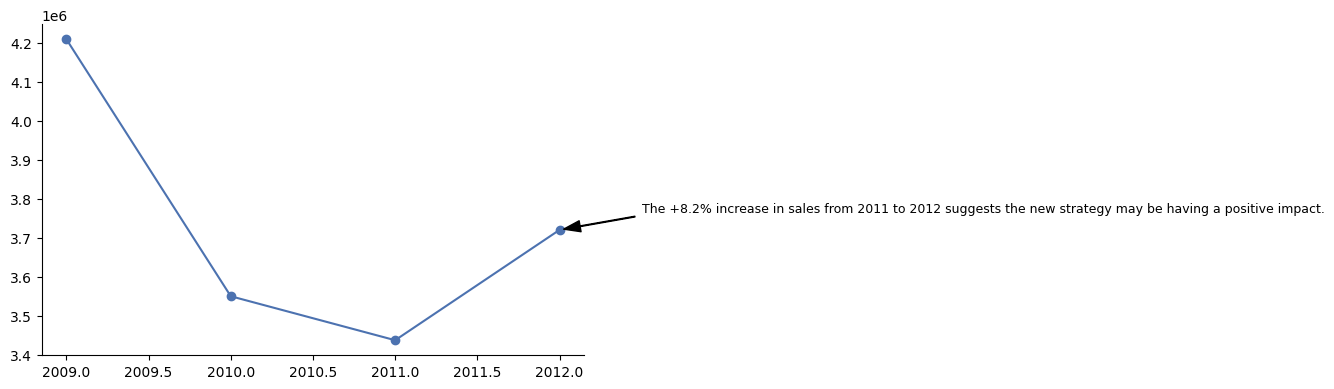

In [9]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# TODO 1: your rewrites
descriptive_version = f"Sales increased by {pct_change:+.1f}% from {y1} to {y2}."
interpretive_version = f"The {pct_change:+.1f}% increase in sales from {y1} to {y2} suggests the new strategy may be having a positive impact."

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2: plot with your interpretive annotation on the last data point
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
# TODO: ax.annotate(...) using interpretive_version, pointing at the last year's value
ax.annotate(interpretive_version, xy=(y2, v2), xytext=(y2 + 0.5, v2 * 1.01),
            arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=8),
            ha='left', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_